**Lets Work on taitanic**

In [55]:
import pandas as pd
import numpy as np         
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df = sns.load_dataset("titanic")
print(df)

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_male deck  embark_town alive  alo

**Basic Info**


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


**Detailed Analysis**

In [58]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


***Calculating Missing Or Null Atributes***

***Overall view Picture of Missing Values Using Seaborn HeatMap***

<Axes: >

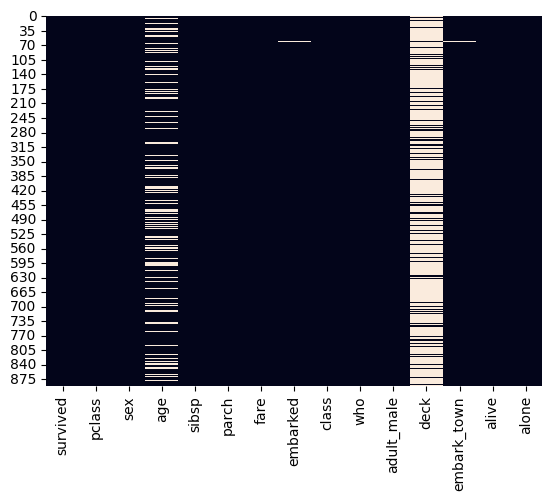

In [59]:
# White lines represents null values 
sns.heatmap(df.isnull(),cbar = False)

In [60]:
# Missing values
# df.isnull().sum()
df.isnull().sum()/len(df)*100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

***Missing Values And Imputing Them***

In [61]:
# We Should Always Remove or drop the Missing Value Atribute which have more than 70% missing values(it will me considered as non existent data)
# By adding inplace=True we deleted the whole columns with its column name,
# # without inplace Column would have been deleted but its column name would have remained.

df.drop('deck',axis =1 , inplace=True)

In [62]:
# Checking if the column is deleted or not
# As we can see, deck column has been removed successfully

df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [63]:
# Now Find Missing Values which is Required to Fill
# As per below result that value is age and embark_town and embarked
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
embark_town      2
alive            0
alone            0
dtype: int64

In [64]:
df['age'].mean()

np.float64(29.69911764705882)

In [65]:
df['age'].median()

np.float64(28.0)

In [66]:
df['age'].mode()[0]

np.float64(24.0)

In [67]:
# Filling the Missing Values  of Age with the mean value.
df['age'] = df['age'].fillna(df['age'].mean())

In [68]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

In [69]:
# Fill the embarked and embark_town 's Missing Value
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embarked'].mode()[0])

In [70]:
# Now Every Value is Filled
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

<Axes: >

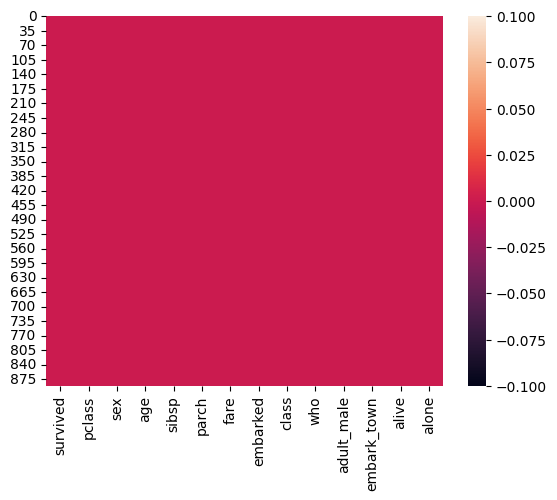

In [71]:
sns.heatmap(df.isnull())

***Binning***

<Axes: xlabel='age', ylabel='Count'>

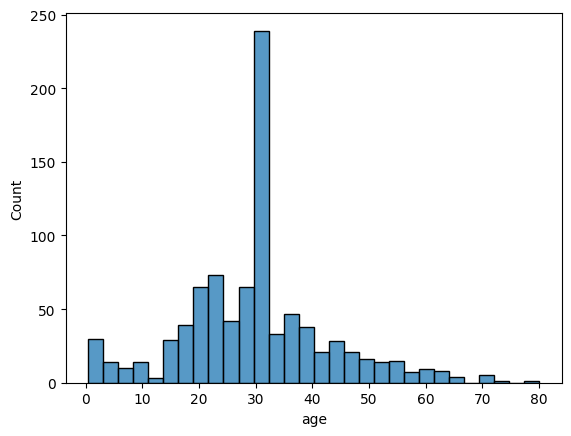

In [72]:
sns.histplot(df['age'])

In [ ]:
# binning of age column into 7 categories
bins = [0,1,5,12,18,30,50,80]
labels = ["Infants","Toddler","Kids","Teens","Youngs","Middle Aged","Old"]

# Converting column based on Bins
pd.cut(df['age'],bins=bins,labels=labels)

0           Youngs
1      Middle Aged
2           Youngs
3      Middle Aged
4      Middle Aged
          ...     
886         Youngs
887         Youngs
888         Youngs
889         Youngs
890    Middle Aged
Name: age, Length: 891, dtype: category
Categories (7, object): ['Infants' < 'Toddler' < 'Kids' < 'Teens' < 'Youngs' < 'Middle Aged' < 'Old']

***Feature Engineering***

In [ ]:
# Adding a new column for binned categories
df["binned_age"]=pd.cut(df['age'],bins=bins,labels=labels)

# Checking columns to confirm
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone', 'binned_age'],
      dtype='object')

In [ ]:
# Counting values in binned_age column
df['binned_age'].value_counts()

binned_age
Youngs         447
Middle Aged    241
Teens           70
Old             64
Toddler         30
Kids            25
Infants         14
Name: count, dtype: int64

***Renaming a column***

In [80]:
df.rename(columns={'binned_age':'age_group'} , inplace = True)

#checking its changed or not
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone', 'age_group'],
      dtype='object')

***Data Filteration***

In [81]:
# based on column
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone', 'age_group'],
      dtype='object')

In [ ]:
# Partition of data based on columns
df_01 = df[['survived','fare','class','age_group']]
df_01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   survived   891 non-null    int64   
 1   fare       891 non-null    float64 
 2   class      891 non-null    category
 3   age_group  891 non-null    category
dtypes: category(2), float64(1), int64(1)
memory usage: 16.3 KB


In [84]:
df['class'].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

In [ ]:
# filter the data based on rows criteria
# THis can be used for those columns which have few catogeries or non-numeric data
df_first = df_01[df_01['class']=='First']
df_first.info()

<class 'pandas.core.frame.DataFrame'>
Index: 216 entries, 1 to 889
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   survived   216 non-null    int64   
 1   fare       216 non-null    float64 
 2   class      216 non-null    category
 3   age_group  216 non-null    category
dtypes: category(2), float64(1), int64(1)
memory usage: 6.0 KB


In [94]:
# For numeric data
df_200 =df_first[df_first['fare'] > 200]
df_200.info()


<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 27 to 779
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   survived   20 non-null     int64   
 1   fare       20 non-null     float64 
 2   class      20 non-null     category
 3   age_group  20 non-null     category
dtypes: category(2), float64(1), int64(1)
memory usage: 1008.0 bytes


In [96]:
df_01[(df_01['fare'] > 70) & (df_01['class']=='First') ].sort_values(by='fare')

,survived,fare,class,age_group
540,1,71.0000,First,Middle Aged
745,0,71.0000,First,Old
1,1,71.2833,First,Middle Aged
366,1,75.2500,First,Old
218,1,76.2917,First,Middle Aged
...,...,...,...,...
341,1,263.0000,First,Youngs
438,0,263.0000,First,Old
258,1,512.3292,First,Middle Aged
737,1,512.3292,First,Middle Aged
